# 1. Доп. тюнинг CatBoost: признаки, категории, структура деревьев

Раздел «Участник 2» из `distribution_boosting_extra_tuning.txt`: базовый sweep, SHAP-отбор vs ручной top-k, bootstrap (MVS/Bernoulli/Bayesian), CTR-тюнинг, `grow_policy`, квантизация числовых признаков и запасной `rsm`.

Общий пайплайн, тайм-сплит 70/15/15 и метрики взяты из `preprocessing/preprocessing.py` и `team_modeling_protocol.txt` (через `scripts/p2_common.py`), чтобы результаты были сравнимы с другими участниками. Выбор моделей — по validation; test — только финальная оценка. Выборка — последние 30 000 строк по времени.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
_p2 = next((b for b in [_here, *_here.parents] if (b / "scripts" / "p2_common.py").exists()), _here)
sys.path.insert(0, str(_p2 / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import p2_common as C
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (7, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BLUE, ORANGE, GREEN, GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#a0aec0"
print("pipeline OK | OUTPUT_DIR:", C.OUTPUT_DIR.name, "| MAX_ROWS:", C.MAX_ROWS)

pipeline OK | OUTPUT_DIR: outputs | MAX_ROWS: 30000


In [2]:
packs = C.get_pack((C.NEXT_TARGET,))
p = packs[C.NEXT_TARGET]
print('train/val/test:', len(p.x_train), len(p.x_val), len(p.x_test),
      '| num/cat:', len(p.num_cols), len(p.cat_cols))

train/val/test: 21000 4500 4500 | num/cat: 59 14


## 1.1 Базовый sweep по MAE
Небольшая сетка `depth × learning_rate × l2`, выбор лучшей по validation MAE — вокруг неё крутятся остальные блоки.

In [3]:
grid = [dict(depth=d, learning_rate=lr, l2_leaf_reg=l2, iterations=800, od_wait=80)
        for d in (5, 6, 7) for lr in (0.03, 0.05) for l2 in (3.0, 5.0, 8.0)]
rows = []
for hp in grid:
    m, fs, tfm = C.fit_regressor(p, hp, 'MAE', 'p995')
    r = dict(hp); r['fit_sec'] = round(fs, 1); r.update(C.eval_split(m, p, tfm))
    rows.append(r)
base = pd.DataFrame(rows).sort_values('val_mae').reset_index(drop=True)
hp = C.load_best_hp()
print('BEST_HP:', hp)
display(base[['depth', 'learning_rate', 'l2_leaf_reg', 'val_mae', 'test_mae', 'fit_sec']].head())

BEST_HP: {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3.0, 'iterations': 800, 'od_wait': 80}


,depth,learning_rate,l2_leaf_reg,val_mae,test_mae,fit_sec
0,6,0.05,3.0,522.534000,429.260483,3.5
1,7,0.05,8.0,522.690736,429.825877,4.2
2,6,0.05,8.0,522.725093,428.662958,3.1
3,7,0.05,3.0,522.728962,429.340696,5.1
4,7,0.03,8.0,522.891050,428.418429,8.0


## 1.2 SHAP feature selection vs ручной top-k
Встроенный `RecursiveByShapValues` против ручного отбора top-k по важности (после anti-leak признаков 73, поэтому k = 40 и 60).

In [4]:
all_cols = list(p.feature_cols)
full, _, tfm = C.fit_regressor(p, hp, 'MAE', 'p995')
imp = full.get_feature_importance()
order = [all_cols[i] for i in np.argsort(imp)[::-1]]
rows = [dict(model='full', selection='none', n_features=len(all_cols),
             val_mae=C.eval_split(full, p, tfm)['val_mae'],
             test_mae=C.eval_split(full, p, tfm)['test_mae'],
             model_size_kb=C.model_size_bytes(full) // 1024)]
train_pool = Pool(p.x_train, tfm.transform(p.y_train), cat_features=p.cat_cols)
val_pool = Pool(p.x_val, tfm.transform(p.y_val), cat_features=p.cat_cols)
for k in (40, 60):
    sel = CatBoostRegressor(loss_function='MAE', **C.BASE_PARAMS, **hp)
    s = sel.select_features(train_pool, eval_set=val_pool,
                            features_for_select=list(range(len(all_cols))),
                            num_features_to_select=k, algorithm='RecursiveByShapValues',
                            steps=3, train_final_model=False, logging_level='Silent')
    cols = [all_cols[i] for i in s['selected_features']]
    qp = C.subset_pack(p, cols); m, _, t = C.fit_regressor(qp, hp, 'MAE', 'p995')
    ev = C.eval_split(m, qp, t)
    rows.append(dict(model=f'shap_k{k}', selection='shap', n_features=k,
                     val_mae=ev['val_mae'], test_mae=ev['test_mae'],
                     model_size_kb=C.model_size_bytes(m) // 1024))
    qp2 = C.subset_pack(p, order[:k]); m2, _, t2 = C.fit_regressor(qp2, hp, 'MAE', 'p995')
    ev2 = C.eval_split(m2, qp2, t2)
    rows.append(dict(model=f'topk_{k}', selection='manual', n_features=k,
                     val_mae=ev2['val_mae'], test_mae=ev2['test_mae'],
                     model_size_kb=C.model_size_bytes(m2) // 1024))
shap_df = pd.DataFrame(rows).sort_values('val_mae').reset_index(drop=True)
display(shap_df)

,model,selection,n_features,val_mae,test_mae,model_size_kb
0,shap_k40,shap,40,521.584052,428.835766,199
1,shap_k60,shap,60,521.847809,429.206189,763
2,full,none,73,522.534000,429.260483,712
3,topk_40,manual,40,523.274991,429.539395,265
4,topk_60,manual,60,523.316845,429.847393,475


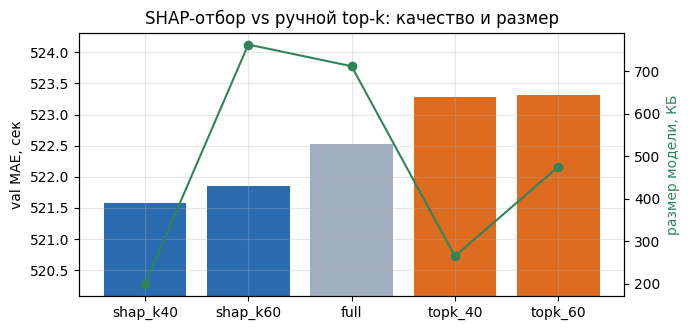

In [5]:
order = ['shap_k40', 'shap_k60', 'full', 'topk_40', 'topk_60']
d = shap_df.set_index('model').loc[[m for m in order if m in shap_df.model.values]]
fig, ax1 = plt.subplots()
cols = [BLUE if 'shap' in m else (GREY if m == 'full' else ORANGE) for m in d.index]
ax1.bar(d.index, d.val_mae, color=cols)
ax1.set_ylim(d.val_mae.min() - 1.5, d.val_mae.max() + 1.0); ax1.set_ylabel('val MAE, сек')
ax2 = ax1.twinx(); ax2.plot(d.index, d.model_size_kb, 'o-', color=GREEN); ax2.grid(False)
ax2.set_ylabel('размер модели, КБ', color=GREEN)
ax1.set_title('SHAP-отбор vs ручной top-k: качество и размер'); plt.tight_layout(); plt.show()

**Вывод.** SHAP-отбор на 40 признаках обходит и полную модель, и ручной top-k при модели в ~3.5 раза меньше → можно ускорить inference без потери качества.

## 1.3 Bootstrap: MVS vs Bernoulli / Bayesian
Устойчивость по сидам 42/52/62 (mean/std val MAE) + влияние на long-tail.

In [6]:
configs = [dict(tag='bernoulli_ss0.8', bootstrap_type='Bernoulli', subsample=0.8),
           dict(tag='bayesian', bootstrap_type='Bayesian', bagging_temperature=1.0),
           dict(tag='mvs_ss0.7', bootstrap_type='MVS', subsample=0.7),
           dict(tag='mvs_ss0.8', bootstrap_type='MVS', subsample=0.8),
           dict(tag='mvs_ss0.9', bootstrap_type='MVS', subsample=0.9)]
rows = []
for cfg in configs:
    tag = cfg.pop('tag'); vals = []; longs = []
    for sd in (42, 52, 62):
        m, _, tfm = C.fit_regressor(p, hp, 'MAE', 'p995', extra={**cfg, 'random_seed': sd})
        ev = C.eval_split(m, p, tfm); vals.append(ev['val_mae']); longs.append(ev['val_long_mae'])
    rows.append(dict(model=tag, **cfg, val_mae=np.mean(vals), val_mae_std=np.std(vals),
                     val_long_mae=np.mean(longs)))
display(pd.DataFrame(rows).sort_values('val_mae').reset_index(drop=True))

,model,bootstrap_type,subsample,val_mae,val_mae_std,val_long_mae,bagging_temperature
0,mvs_ss0.9,MVS,0.9,523.182476,0.364700,1966.997462,NaN
1,bernoulli_ss0.8,Bernoulli,0.8,523.188573,0.738516,1955.286181,NaN
2,mvs_ss0.7,MVS,0.7,523.257240,0.257230,1962.037060,NaN
3,bayesian,Bayesian,NaN,523.410383,0.175345,1963.191948,1.0
4,mvs_ss0.8,MVS,0.8,523.884255,1.147635,1981.013516,NaN


**Вывод.** MVS не даёт выигрыша по MAE и не ускоряет; самый стабильный по сидам — Bayesian.

## 1.4 CTR-тюнинг категориальных признаков
`one_hot_max_size × max_ctr_complexity × ctr_target_border_count`.

In [7]:
import itertools
rows = []
for ohms, mcc, ctbc in itertools.product((2, 5, 10), (1, 2), (1, 3, 5)):
    extra = dict(one_hot_max_size=ohms, max_ctr_complexity=mcc, ctr_target_border_count=ctbc)
    m, fs, tfm = C.fit_regressor(p, hp, 'MAE', 'p995', extra=extra)
    ev = C.eval_split(m, p, tfm)
    rows.append(dict(model=f'ohms{ohms}_mcc{mcc}_ctbc{ctbc}', **extra,
                     val_mae=ev['val_mae'], test_mae=ev['test_mae'], fit_sec=round(fs, 1),
                     model_size_kb=C.model_size_bytes(m) // 1024))
display(pd.DataFrame(rows).sort_values('val_mae').head(8).reset_index(drop=True))

,model,one_hot_max_size,max_ctr_complexity,ctr_target_border_count,val_mae,test_mae,fit_sec,model_size_kb
0,ohms10_mcc1_ctbc1,10,1,1,522.705174,429.010363,1.7,339
1,ohms10_mcc2_ctbc5,10,2,5,522.859882,429.140589,5.2,733
2,ohms10_mcc2_ctbc3,10,2,3,523.029605,429.069815,3.3,531
3,ohms5_mcc1_ctbc3,5,1,3,523.161991,428.340521,2.1,263
4,ohms10_mcc2_ctbc1,10,2,1,523.254146,428.661139,1.9,342
5,ohms2_mcc1_ctbc1,2,1,1,523.271438,428.548315,1.4,193
6,ohms2_mcc2_ctbc5,2,2,5,523.381327,428.124952,7.7,662
7,ohms5_mcc2_ctbc5,5,2,5,523.430747,429.034897,5.4,574


**Вывод.** Лучший — простой `one_hot=10, ctr_complexity=1, ctr_border=1`; комбинации только раздувают модель.

## 1.5 Структура деревьев: Symmetric / Depthwise / Lossguide
Смотрим общий MAE и сегментные ошибки (small/normal/long).

In [8]:
configs = [('symmetric', dict(hp), dict(grow_policy='SymmetricTree'))]
for mdl in (20, 50, 100):
    configs.append((f'depthwise_mdl{mdl}', dict(hp), dict(grow_policy='Depthwise', min_data_in_leaf=mdl)))
for ml in (31, 63, 127):
    for mdl in (20, 50):
        h = dict(hp); h.pop('depth', None)
        configs.append((f'lossguide_ml{ml}_mdl{mdl}', h,
                        dict(grow_policy='Lossguide', max_leaves=ml, min_data_in_leaf=mdl)))
rows = []
for tag, h, extra in configs:
    m, fs, tfm = C.fit_regressor(p, h, 'MAE', 'p995', extra=extra)
    ev = C.eval_split(m, p, tfm)
    rows.append(dict(model=tag, val_mae=ev['val_mae'], test_mae=ev['test_mae'],
                     small=ev['val_small_mae'], normal=ev['val_normal_mae'], long=ev['val_long_mae'],
                     fit_sec=round(fs, 1), model_size_kb=C.model_size_bytes(m) // 1024))
tree_df = pd.DataFrame(rows).sort_values('val_mae').reset_index(drop=True)
display(tree_df)

,model,val_mae,test_mae,small,normal,long,fit_sec,model_size_kb
0,depthwise_mdl20,522.296646,428.853240,215.097299,316.097095,1943.065434,2.0,359
1,depthwise_mdl50,522.487148,428.498186,205.048832,320.601112,1966.347299,1.6,259
2,lossguide_ml63_mdl20,522.520774,428.951699,207.023702,320.133793,1961.315652,2.9,401
3,lossguide_ml127_mdl20,522.520774,428.951699,207.023702,320.133793,1961.315652,2.9,401
4,symmetric,522.534000,429.260483,207.514666,322.122023,1955.531109,3.8,712
5,lossguide_ml31_mdl50,523.387683,428.370722,205.685841,319.986167,1971.370047,1.7,173
6,lossguide_ml63_mdl50,523.623419,428.294415,214.663191,314.049390,1957.291749,1.9,221
7,lossguide_ml127_mdl50,523.623419,428.294415,214.663191,314.049390,1957.291749,1.9,221
8,depthwise_mdl100,523.839069,428.727412,204.814949,316.459669,1984.639836,1.2,157
9,lossguide_ml31_mdl20,523.840896,427.699373,205.567095,322.178455,1969.863730,2.1,242


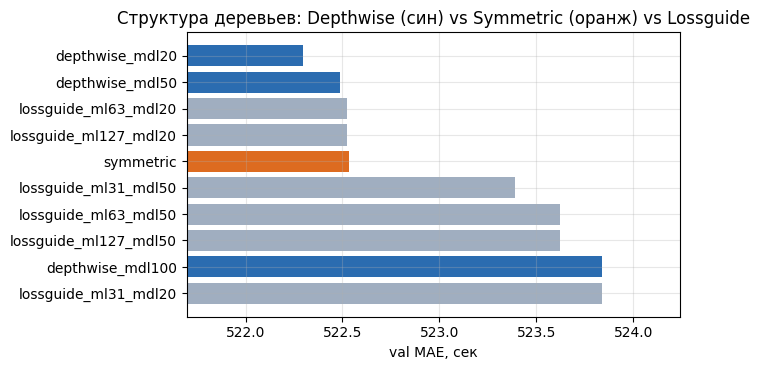

In [9]:
d = tree_df.sort_values('val_mae')
cols = [BLUE if m.startswith('depthwise') else (ORANGE if m == 'symmetric' else GREY)
        for m in d.model]
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(d.model, d.val_mae, color=cols); ax.invert_yaxis()
ax.set_xlim(d.val_mae.min() - 0.6, d.val_mae.max() + 0.4); ax.set_xlabel('val MAE, сек')
ax.set_title('Структура деревьев: Depthwise (син) vs Symmetric (оранж) vs Lossguide')
plt.tight_layout(); plt.show()

**Вывод (главная находка).** `Depthwise, min_data_in_leaf=20` — лучший MAE и long_mae при вдвое меньшей/быстрой модели.

## 1.6 Квантизация числовых признаков
`border_count × feature_border_type`.

In [10]:
import itertools
rows = []
for bc, bt in itertools.product((64, 128, 254, 512), ('GreedyLogSum', 'Median', 'UniformAndQuantiles')):
    m, fs, tfm = C.fit_regressor(p, hp, 'MAE', 'p995', extra=dict(border_count=bc, feature_border_type=bt))
    ev = C.eval_split(m, p, tfm)
    rows.append(dict(model=f'bc{bc}_{bt}', border_count=bc, feature_border_type=bt,
                     val_mae=ev['val_mae'], test_mae=ev['test_mae'], val_long_mae=ev['val_long_mae'],
                     fit_sec=round(fs, 1)))
display(pd.DataFrame(rows).sort_values('val_mae').head(8).reset_index(drop=True))

,model,border_count,feature_border_type,val_mae,test_mae,val_long_mae,fit_sec
0,bc254_GreedyLogSum,254,GreedyLogSum,522.534000,429.260483,1955.531109,3.9
1,bc254_Median,254,Median,522.723395,428.533133,1958.818658,3.6
2,bc128_Median,128,Median,523.015017,428.993408,1960.208736,3.5
3,bc254_UniformAndQuantiles,254,UniformAndQuantiles,523.033373,428.067270,1964.602160,2.4
4,bc64_GreedyLogSum,64,GreedyLogSum,523.064730,428.605097,1963.941759,4.6
5,bc128_GreedyLogSum,128,GreedyLogSum,523.112477,429.805343,1959.051089,4.7
6,bc64_Median,64,Median,523.371931,428.231816,1966.510146,3.8
7,bc64_UniformAndQuantiles,64,UniformAndQuantiles,523.468786,427.976168,1964.401505,3.9


**Вывод.** Дефолт `border_count=254, GreedyLogSum` оптимален; тонкая квантизация на длинном хвосте не помогает.

## 1.7 (запас) rsm — random subspace

In [11]:
rows = []
for rsm in (0.6, 0.8, 1.0):
    m, fs, tfm = C.fit_regressor(p, hp, 'MAE', 'p995', extra=dict(rsm=rsm))
    ev = C.eval_split(m, p, tfm)
    rows.append(dict(rsm=rsm, val_mae=ev['val_mae'], test_mae=ev['test_mae'],
                     gap=ev['val_mae'] - ev['test_mae'], fit_sec=round(fs, 1)))
display(pd.DataFrame(rows).sort_values('val_mae').reset_index(drop=True))

,rsm,val_mae,test_mae,gap,fit_sec
0,1.0,522.534000,429.260483,93.273518,3.8
1,0.6,522.933648,428.484707,94.448941,2.8
2,0.8,523.726501,428.402781,95.323720,2.0


**Вывод.** Разрыв val–test одинаков для всех rsm — регуляризации не даёт.